In [2]:
from google.colab import files
uploaded =files.upload()


Saving totalempresas_unificadas.xlsx to totalempresas_unificadas.xlsx


In [3]:
import pandas as pd

df = pd.read_excel('totalempresas_unificadas.xlsx')
df.head()

,ORGANIZACION,RAZON SOCIAL,NIT,FEC-MATRICULA,FEC-RENOVACION,MUN-COMERCIAL,EMAIL-COMERCIAL,CIIU-1,CIIU-2,TAM-EMPRESA,...,EMPRESA,FECHA_REGISTRO,FECHA_RENOVACION,VALOR_ACTIVOS,CODIGO_ACTIVIDAD_PRINCIPAL,CODIGO_ACTIVIDAD_SECUNDARIA,TIPO_EMPRESA,TIPO_ORGANIZACION,SECTOR_PERTENECE,ID_EMPRESA
0,16,LIMPIAMOS SAN ANDRES SAS,8.000.618.831,19.890.914,20.220.331,88001 - SAN ANDRES,limpiamossanandres@yahoo.com,N8129 ** Otras actividades de limpieza de edif...,NaN,MICRO EMPRESA,...,NAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000.618.831
1,2,LIMPIAMOS SAN ANDRES,NaN,19.890.914,20.220.331,88001 - SAN ANDRES,limpiamossanandres@yahoo.com,N8129 ** Otras actividades de limpieza de edif...,N8129 ** Otras actividades de limpieza de edif...,NaN,...,NAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LIMPIAMOS SAN ANDRES
2,3,GALLARDO CORPUS Y COMPANIA LIMITADA,8.000.761.354,19.890.922,20.220.208,88001 - SAN ANDRES,marymayinn@gmail.com,I5511 ** Alojamiento en hoteles,NaN,MICRO EMPRESA,...,NAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000.761.354
3,6,INVERSIONES DETALLES ARCHBOLD CERON & CIA S. E...,8.000.647.201,19.890.928,20.220.331,88001 - SAN ANDRES,lemasai@gmail.com,I5511 ** Alojamiento en hoteles,NaN,MICRO EMPRESA,...,NAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000.647.201
4,2,S-C.M.A. DISTRIBUCIONES,NaN,19.900.104,20.220.617,88001 - SAN ANDRES,nanao67@hotmail.com,G4669 ** Comercio al por mayor de otros produc...,NaN,NaN,...,NAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S-C.M.A. DISTRIBUCIONES


In [4]:
df.columns

Index(['ORGANIZACION', 'RAZON SOCIAL', 'NIT', 'FEC-MATRICULA',
       'FEC-RENOVACION', 'MUN-COMERCIAL', 'EMAIL-COMERCIAL', 'CIIU-1',
       'CIIU-2', 'TAM-EMPRESA', 'DEPARTAMENTO', 'MUNICIPIO', 'MATRICULA',
       'ACTIVO-CORRIENTE', 'ACTIVIDAD', 'CIIU-TAM-EMPRESARIAL', 'EMPRESA',
       'FECHA_REGISTRO', 'FECHA_RENOVACION', 'VALOR_ACTIVOS',
       'CODIGO_ACTIVIDAD_PRINCIPAL', 'CODIGO_ACTIVIDAD_SECUNDARIA',
       'TIPO_EMPRESA', 'TIPO_ORGANIZACION', 'SECTOR_PERTENECE', 'ID_EMPRESA'],
      dtype='object')

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39822 entries, 0 to 39821
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ORGANIZACION                 15501 non-null  object 
 1   RAZON SOCIAL                 39822 non-null  object 
 2   NIT                          1054 non-null   object 
 3   FEC-MATRICULA                15501 non-null  object 
 4   FEC-RENOVACION               15501 non-null  object 
 5   MUN-COMERCIAL                5593 non-null   object 
 6   EMAIL-COMERCIAL              5593 non-null   object 
 7   CIIU-1                       15501 non-null  object 
 8   CIIU-2                       7537 non-null   object 
 9   TAM-EMPRESA                  10651 non-null  object 
 10  DEPARTAMENTO                 39822 non-null  object 
 11  MUNICIPIO                    39822 non-null  object 
 12  MATRICULA                    9908 non-null   float64
 13  ACTIVO-CORRIENTE

In [6]:
df = df.copy()

# Normalizar nombres de columnas
df.columns = df.columns.str.strip().str.upper()

# Ver nulos
df.isnull().sum()

,0
ORGANIZACION,24321
RAZON SOCIAL,0
NIT,38768
FEC-MATRICULA,24321
FEC-RENOVACION,24321
MUN-COMERCIAL,34229
EMAIL-COMERCIAL,34229
CIIU-1,24321
CIIU-2,32285
TAM-EMPRESA,29171


In [7]:
df_san_andres = df[df['DEPARTAMENTO'].str.contains('SAN ANDRES', case=False, na=False)]

df_san_andres.shape

(0, 26)

In [ ]:
df['DEPARTAMENTO'].unique()

array(['NAN', 'VALLE DEL CAUCA', 'SUCRE', 'SANTANDER', 'PUTUMAYO',
       'BOGOTA'], dtype=object)

In [9]:
df_valle = df[df['DEPARTAMENTO'] == 'VALLE DEL CAUCA']

In [10]:
df['DEPARTAMENTO'].value_counts()

,count
DEPARTAMENTO,
SUCRE,24316
VALLE DEL CAUCA,9908
NAN,5593
SANTANDER,3
PUTUMAYO,1
BOGOTA,1


In [11]:
df_valle = df[df['DEPARTAMENTO'] == 'VALLE DEL CAUCA']
df_valle.shape

(9908, 26)

In [12]:
df_valle = df_valle.copy()

# Convertir fechas
df_valle['FEC-MATRICULA'] = pd.to_datetime(df_valle['FEC-MATRICULA'], errors='coerce')

# Crear año
df_valle['AÑO'] = df_valle['FEC-MATRICULA'].dt.year

/tmp/ipykernel_12229/2916300282.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_valle['FEC-MATRICULA'] = pd.to_datetime(df_valle['FEC-MATRICULA'], errors='coerce')


In [13]:
df_valle['TAM-EMPRESA'].value_counts()

,count
TAM-EMPRESA,
MICRO EMPRESA,9445
PEQUEÑA EMPRESA,142
MEDIANA EMPRESA,25
GRAN EMPRESA,5


In [14]:
df_valle['AÑO'].value_counts().sort_index()

,count
AÑO,


In [15]:
df_valle['MUNICIPIO'].value_counts().head(10)

,count
MUNICIPIO,
TULUA,9908


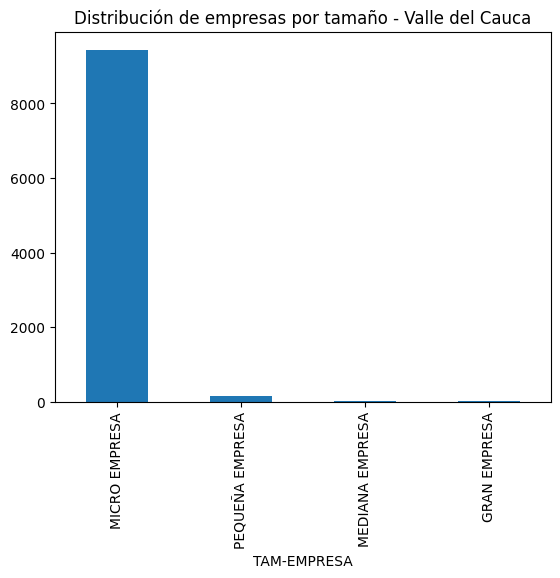

In [16]:
import matplotlib.pyplot as plt

df_valle['TAM-EMPRESA'].value_counts().plot(kind='bar')
plt.title('Distribución de empresas por tamaño - Valle del Cauca')
plt.show()

### Insight
Se observa que el departamento con más empresas es Valle del Cauca, lo que puede indicar mayor actividad comercial en esta región o sus datos estan mas actualizados.
## Municipio con mas empresas registradas
Actualmente el municipío con mas empresas registradas es Tulua, lo que representa con volumen importante, casi toda su mayoria, podria significar un sesgo de datos.
##Tamaño de empresas
en base a esta informacion la predominancia en el valle son las microempresas.

In [17]:
df_valle.shape
df_valle['TAM-EMPRESA'].value_counts()
df_valle['CIIU-1'].value_counts().head(5)

,count
CIIU-1,
G4711 ** Comercio al por menor en establecimientos no especializados con surtido compuesto principalmente por alimentos bebidas (alcohólicas y no alcohólicas) o tabaco,517
I5611 ** Expendio a la mesa de comidas preparadas,447
G4773 ** Comercio al por menor de productos farmaceuticos y medicinales cosmeticos y articulos de tocador en establecimientos especializados,422
G4771 ** Comercio al por menor de prendas de vestir y sus accesorios (incluye articulos de piel) en establecimientos especializados,399
I5619 ** Otros tipos de expendio de comidas preparadas n.c.p.,368


##Economía basada en consumo

El tejido empresarial del Valle del Cauca está fuertemente concentrado en actividades de consumo básico, especialmente comercio minorista de alimentos y servicios de comida.

##Alta presencia de servicios

Los sectores relacionados con alimentos preparados (restaurantes) tienen una participación significativa, lo que refleja una economía orientada al servicio.

##Baja diversificación

La concentración en pocos sectores puede indicar una limitada diversificación económica, con predominio del comercio y servicios sobre actividades industriales o tecnológicas.

##Economía urbana

La fuerte presencia de comercio y restaurantes sugiere alta actividad en zonas urbanas, posiblemente concentradas en ciudades principales como Cali.

In [18]:
df_valle['FEC-MATRICULA'].head(10)

,FEC-MATRICULA
5593,NaT
5594,NaT
5595,NaT
5596,NaT
5597,NaT
5598,NaT
5599,NaT
5600,NaT
5601,NaT
5602,NaT


In [19]:
df_valle['FEC-MATRICULA'].astype(str).head(20)

,FEC-MATRICULA
5593,NaT
5594,NaT
5595,NaT
5596,NaT
5597,NaT
5598,NaT
5599,NaT
5600,NaT
5601,NaT
5602,NaT


In [20]:
df_valle['FEC-MATRICULA'] = pd.to_datetime(
    df_valle['FEC-MATRICULA'],
    errors='coerce',
    dayfirst=True
)

In [21]:
df_valle['FEC-MATRICULA'].notnull().sum()

np.int64(0)

In [22]:
df_valle['MUNICIPIO'].value_counts(normalize=True).head(5)

,proportion
MUNICIPIO,
TULUA,1.0
